In [ ]:
# Bibliotecas básicas
!pip install adafruit-io requests matplotlib pandas -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 605.2 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.6 MB/s eta 0:00:00
✅ Bibliotecas instaladas!


In [ ]:
# ============================================
# Célula 2: Configuração e Imports
# ============================================
import time
import random
import datetime
import matplotlib.pyplot as plt
import pandas as pd
from Adafruit_IO import Client, Feed, Data
import requests
import json

In [ ]:
# Configurações do Adafruit IO
print("📝 Configure suas credenciais do Adafruit IO:")
print("1. Acesse: https://io.adafruit.com")
print("2. Clique no ícone de chave amarela")
print("3. Copie seu Username e Active Key")
print("-" * 50)


📝 Configure suas credenciais do Adafruit IO:
1. Acesse: https://io.adafruit.com
2. Clique no ícone de chave amarela
3. Copie seu Username e Active Key
--------------------------------------------------


In [ ]:
ADAFRUIT_IO_USERNAME = "vitorpq"
ADAFRUIT_IO_KEY      = "aio_fXWU53OVFGZQFSw8l9Mmst24E0GX"

In [ ]:
# ============================================
# Célula 3: Classe de Simulação IoT
# ============================================
class SimuladorIoT:
    """Simula um dispositivo IoT enviando dados"""

    def __init__(self, username, key):
        self.client = Client(username, key)
        self.feeds = {}
        print("✅ Cliente Adafruit IO conectado!")

    def criar_feeds(self):
        """Cria os feeds necessários"""
        feeds_info = {
            'temperatura': 'Temperatura em °C',
            'umidade': 'Umidade Relativa %',
            'luminosidade': 'Luminosidade em Lux',
            'movimento': 'Sensor de Movimento'
        }

        for nome, descricao in feeds_info.items():
            try:
                # Tenta buscar feed existente
                feed = self.client.feeds(nome)
                print(f"✅ Feed '{nome}' já existe")
            except:
                # Cria novo feed
                feed = Feed(name=nome, description=descricao)
                feed = self.client.create_feed(feed)
                print(f"✅ Feed '{nome}' criado")

            self.feeds[nome] = feed

    def gerar_dados_sensor(self, tipo='temperatura'):
        """Gera dados simulados de sensores"""
        hora_atual = datetime.datetime.now().hour

        if tipo == 'temperatura':
            # Simula variação de temperatura durante o dia
            base = 20 + 5 * abs(12 - hora_atual) / 12
            return round(base + random.uniform(-2, 2), 1)

        elif tipo == 'umidade':
            # Umidade inversamente proporcional à temperatura
            return round(70 - random.uniform(0, 20), 1)

        elif tipo == 'luminosidade':
            # Luminosidade baseada na hora do dia
            if 6 <= hora_atual <= 18:
                return round(500 + random.uniform(-100, 100))
            else:
                return round(50 + random.uniform(-20, 20))

        elif tipo == 'movimento':
            # Movimento aleatório (0 ou 1)
            return random.choice([0, 1])

    def enviar_dados(self, feed_name, valor):
        """Envia dados para um feed"""
        try:
            self.client.send_data(feed_name, valor)
            return True
        except Exception as e:
            print(f"❌ Erro ao enviar: {e}")
            return False



In [ ]:
# ============================================
# Célula 4: Inicialização e Teste
# ============================================
# Inicializa o simulador após preencher as credenciais
simulador = SimuladorIoT(ADAFRUIT_IO_USERNAME, ADAFRUIT_IO_KEY)
simulador.criar_feeds()
# if username_widget.value and key_widget.value:
#     simulador = SimuladorIoT(username_widget.value, key_widget.value)
#     simulador.criar_feeds()
# else:
#     print("⚠️ Por favor, preencha suas credenciais acima!")



✅ Cliente Adafruit IO conectado!
✅ Feed 'temperatura' já existe
✅ Feed 'umidade' já existe
✅ Feed 'luminosidade' já existe
✅ Feed 'movimento' já existe


📡 ENVIANDO DADOS - Leitura #7
⏱️  Tempo decorrido: 35s
--------------------------------------------------
✅ Temperatura: 23.2°C
✅ Umidade: 62.9%
✅ Luminosidade: 479 lux
✅ Movimento: Detectado


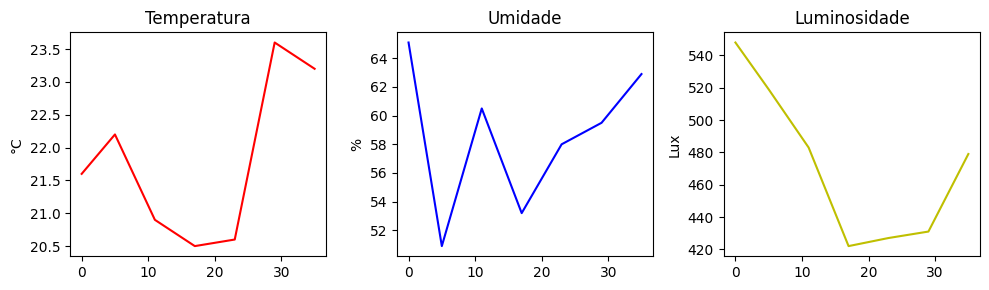


⏹️  Simulação interrompida pelo usuário

✅ Simulação concluída!


In [ ]:
# ============================================
# Célula 5: Simulação em Tempo Real
# ============================================
def simular_dispositivo_iot(duracao_minutos=5, intervalo_segundos=15):
    """
    Simula um dispositivo IoT enviando dados

    Args:
        duracao_minutos: Tempo total de simulação
        intervalo_segundos: Intervalo entre envios
    """
    print(f"🚀 Iniciando simulação por {duracao_minutos} minutos...")
    print(f"📊 Intervalo entre envios: {intervalo_segundos} segundos")
    print("-" * 50)

    # Listas para armazenar dados
    historico = {
        'tempo': [],
        'temperatura': [],
        'umidade': [],
        'luminosidade': [],
        'movimento': []
    }

    tempo_inicio = time.time()
    tempo_fim = tempo_inicio + (duracao_minutos * 60)
    contador = 0

    try:
        while time.time() < tempo_fim:
            contador += 1
            tempo_decorrido = int(time.time() - tempo_inicio)

            # Gera dados dos sensores
            dados = {
                'temperatura': simulador.gerar_dados_sensor('temperatura'),
                'umidade': simulador.gerar_dados_sensor('umidade'),
                'luminosidade': simulador.gerar_dados_sensor('luminosidade'),
                'movimento': simulador.gerar_dados_sensor('movimento')
            }

            # Limpa output anterior
            clear_output(wait=True)

            print(f"📡 ENVIANDO DADOS - Leitura #{contador}")
            print(f"⏱️  Tempo decorrido: {tempo_decorrido}s")
            print("-" * 50)

            # Envia dados e mostra status
            for sensor, valor in dados.items():
                sucesso = simulador.enviar_dados(sensor, valor)
                status = "✅" if sucesso else "❌"

                # Formatação especial para cada tipo
                if sensor == 'temperatura':
                    print(f"{status} {sensor.capitalize()}: {valor}°C")
                elif sensor == 'umidade':
                    print(f"{status} {sensor.capitalize()}: {valor}%")
                elif sensor == 'luminosidade':
                    print(f"{status} {sensor.capitalize()}: {valor} lux")
                elif sensor == 'movimento':
                    estado = "Detectado" if valor == 1 else "Sem movimento"
                    print(f"{status} {sensor.capitalize()}: {estado}")

                # Armazena no histórico
                historico[sensor].append(valor)

            historico['tempo'].append(tempo_decorrido)

            # Mostra mini-gráfico inline
            if len(historico['tempo']) > 1:
                plt.figure(figsize=(10, 3))

                plt.subplot(1, 3, 1)
                plt.plot(historico['tempo'], historico['temperatura'], 'r-')
                plt.title('Temperatura')
                plt.ylabel('°C')

                plt.subplot(1, 3, 2)
                plt.plot(historico['tempo'], historico['umidade'], 'b-')
                plt.title('Umidade')
                plt.ylabel('%')

                plt.subplot(1, 3, 3)
                plt.plot(historico['tempo'], historico['luminosidade'], 'y-')
                plt.title('Luminosidade')
                plt.ylabel('Lux')

                plt.tight_layout()
                plt.show()

            # Aguarda próximo envio
            time.sleep(intervalo_segundos)

    except KeyboardInterrupt:
        print("\n⏹️  Simulação interrompida pelo usuário")

    print("\n✅ Simulação concluída!")
    return pd.DataFrame(historico)

# Executa a simulação
dados_coletados = simular_dispositivo_iot(duracao_minutos=5, intervalo_segundos=15)



In [ ]:
simulador.client.data('temperatura')

[Data(created_epoch=1748540327, created_at='2025-05-29T17:38:47Z', updated_at=None, value='23.2', completed_at=None, feed_id=3102357, expiration='2025-06-28T17:38:47Z', position=None, id='0FWWHM0HGE9NZQX359TV38BF2X', lat=None, lon=None, ele=None),
 Data(created_epoch=1748540321, created_at='2025-05-29T17:38:41Z', updated_at=None, value='23.6', completed_at=None, feed_id=3102357, expiration='2025-06-28T17:38:41Z', position=None, id='0FWWHKYQTJCFZMYJ56YJCKC1WW', lat=None, lon=None, ele=None),
 Data(created_epoch=1748540315, created_at='2025-05-29T17:38:35Z', updated_at=None, value='20.6', completed_at=None, feed_id=3102357, expiration='2025-06-28T17:38:35Z', position=None, id='0FWWHKWX5VMFP2MHCX6BYSEF8F', lat=None, lon=None, ele=None),
 Data(created_epoch=1748540309, created_at='2025-05-29T17:38:29Z', updated_at=None, value='20.5', completed_at=None, feed_id=3102357, expiration='2025-06-28T17:38:29Z', position=None, id='0FWWHKV3R5FW8D08X6HQNCPBS3', lat=None, lon=None, ele=None),
 Data(cr

In [ ]:
# ============================================
# Célula 6: Leitura de Dados do Adafruit IO
# ============================================
def ler_dados_feed(feed_name, limite=50):
    """Lê os últimos dados de um feed"""
    try:
        dados = simulador.client.data(feed_name)

        # Converte para DataFrame
        df_dados = []
        for d in dados[:limite]:
            df_dados.append({
                'valor': float(d.value),
                'tempo': d.created_at,
                'id': d.id
            })

        df = pd.DataFrame(df_dados)
        df['tempo'] = pd.to_datetime(df['tempo'])
        df = df.sort_values('tempo')

        return df
    except Exception as e:
        print(f"❌ Erro ao ler dados: {e}")
        return None

# Exemplo de leitura
print("📊 Lendo dados dos feeds...")
for feed in ['temperatura', 'umidade', 'luminosidade']:
    df = ler_dados_feed(feed, limite=20)
    if df is not None and not df.empty:
        print(f"\n📈 {feed.upper()} - Últimas {len(df)} leituras:")
        print(f"   Média: {df['valor'].mean():.2f}")
        print(f"   Mín: {df['valor'].min():.2f}")
        print(f"   Máx: {df['valor'].max():.2f}")

📊 Lendo dados dos feeds...

📈 TEMPERATURA - Últimas 18 leituras:
   Média: 21.73
   Mín: 20.20
   Máx: 23.70

📈 UMIDADE - Últimas 16 leituras:
   Média: 59.11
   Mín: 50.90
   Máx: 67.30

📈 LUMINOSIDADE - Últimas 16 leituras:
   Média: 497.00
   Mín: 420.00
   Máx: 574.00


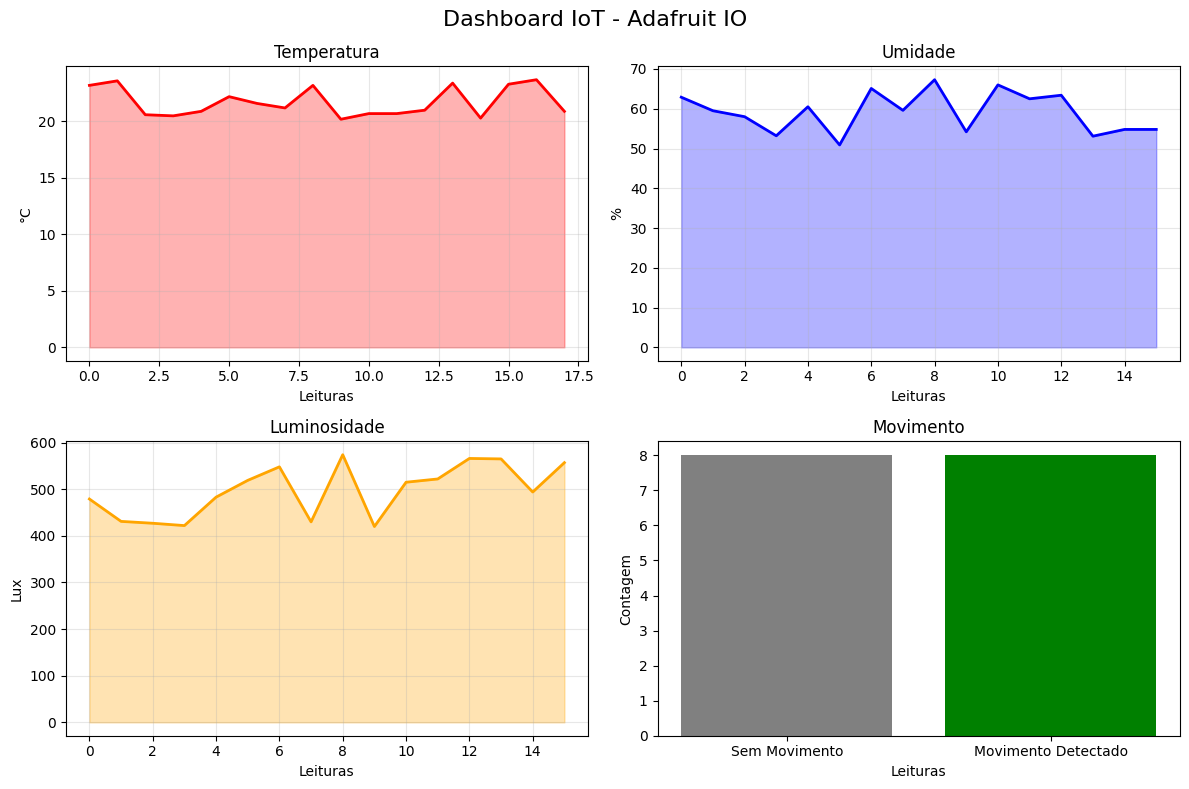

In [ ]:
# ============================================
# Célula 7: Dashboard Interativo
# ============================================
def criar_dashboard():
    """Cria um dashboard interativo com os dados"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Dashboard IoT - Adafruit IO', fontsize=16)

    feeds_config = [
        ('temperatura', axes[0, 0], 'red', '°C'),
        ('umidade', axes[0, 1], 'blue', '%'),
        ('luminosidade', axes[1, 0], 'orange', 'Lux'),
        ('movimento', axes[1, 1], 'green', 'Estado')
    ]

    for feed_name, ax, cor, unidade in feeds_config:
        df = ler_dados_feed(feed_name, limite=50)

        if df is not None and not df.empty:
            if feed_name == 'movimento':
                # Gráfico de barras para movimento
                contagem = df['valor'].value_counts()
                ax.bar(['Sem Movimento', 'Movimento Detectado'],
                      [contagem.get(0, 0), contagem.get(1, 0)],
                      color=['gray', 'green'])
                ax.set_ylabel('Contagem')
            else:
                # Gráfico de linha para outros sensores
                ax.plot(df.index, df['valor'], color=cor, linewidth=2)
                ax.fill_between(df.index, df['valor'], alpha=0.3, color=cor)
                ax.set_ylabel(unidade)
                ax.grid(True, alpha=0.3)

            ax.set_title(f'{feed_name.capitalize()}')
            ax.set_xlabel('Leituras')

    plt.tight_layout()
    plt.show()

# Cria o dashboard
criar_dashboard()


In [ ]:
# ============================================
# Célula 8: Teste de Webhook (Opcional)
# ============================================
def testar_webhook():
    """Testa integração com webhooks do Adafruit IO"""
    print("🔗 Configurando Webhook...")

    # URL do webhook (pode ser um serviço como IFTTT, Zapier, etc)
    webhook_url = "https://maker.ifttt.com/trigger/iot_alert/with/key/YOUR_KEY"

    # Simula alerta de temperatura alta
    temp_atual = simulador.gerar_dados_sensor('temperatura')

    if temp_atual > 30:
        payload = {
            'value1': 'Alerta de Temperatura',
            'value2': f'{temp_atual}°C',
            'value3': 'Temperatura acima do limite!'
        }

        try:
            # response = requests.post(webhook_url, json=payload)
            print(f"⚠️  ALERTA: Temperatura alta detectada: {temp_atual}°C")
            print("📧 Webhook seria acionado (descomente o código para ativar)")
        except:
            print("❌ Erro ao enviar webhook")

testar_webhook()



🔗 Configurando Webhook...


In [ ]:
# ============================================
# Célula 9: Exportar Dados
# ============================================
def exportar_dados_csv():
    """Exporta todos os dados para CSV"""
    print("💾 Exportando dados...")

    todos_dados = {}
    for feed_name in ['temperatura', 'umidade', 'luminosidade', 'movimento']:
        df = ler_dados_feed(feed_name, limite=100)
        if df is not None:
            todos_dados[feed_name] = df

    # Salva cada feed em um CSV
    for feed_name, df in todos_dados.items():
        filename = f'dados_{feed_name}.csv'
        df.to_csv(filename, index=False)
        print(f"✅ Arquivo '{filename}' salvo!")

    # Cria arquivo combinado
    if todos_dados:
        primeiro_feed = list(todos_dados.keys())[0]
        df_combined = todos_dados[primeiro_feed].copy()
        df_combined = df_combined.rename(columns={'valor': primeiro_feed})

        for feed_name in list(todos_dados.keys())[1:]:
            df_temp = todos_dados[feed_name][['tempo', 'valor']]
            df_temp = df_temp.rename(columns={'valor': feed_name})
            df_combined = pd.merge(df_combined, df_temp, on='tempo', how='outer')

        df_combined.to_csv('dados_combinados.csv', index=False)
        print("✅ Arquivo 'dados_combinados.csv' com todos os dados salvo!")

# exportar_dados_csv()



In [ ]:
# ============================================
# Célula 10: Exercícios para Alunos
# ============================================
print("""
📚 EXERCÍCIOS PROPOSTOS:

1. Modifique a função gerar_dados_sensor() para simular:
   - Sensor de CO2 (400-1000 ppm)
   - Sensor de pressão (1000-1020 hPa)

2. Crie uma função que detecte anomalias nos dados:
   - Temperatura > 35°C ou < 10°C
   - Umidade > 90% ou < 20%

3. Implemente um sistema de alertas que:
   - Envie notificação quando valores críticos forem detectados
   - Mantenha log de todos os alertas

4. Crie visualizações avançadas:
   - Heatmap de correlação entre sensores
   - Gráfico de dispersão temperatura vs umidade

5. Desenvolva um preditor simples:
   - Use os últimos 10 valores para prever o próximo (regressao logistica)
   - Compare com o valor real
""")


📚 EXERCÍCIOS PROPOSTOS:

1. Modifique a função gerar_dados_sensor() para simular:
   - Sensor de CO2 (400-1000 ppm)
   - Sensor de pressão (1000-1020 hPa)

2. Crie uma função que detecte anomalias nos dados:
   - Temperatura > 35°C ou < 10°C
   - Umidade > 90% ou < 20%

3. Implemente um sistema de alertas que:
   - Envie notificação quando valores críticos forem detectados
   - Mantenha log de todos os alertas

4. Crie visualizações avançadas:
   - Heatmap de correlação entre sensores
   - Gráfico de dispersão temperatura vs umidade

5. Desenvolva um preditor simples:
   - Use os últimos 10 valores para prever o próximo (regressao logistica)
   - Compare com o valor real

